## Задачи первого этапа исследования:
 1. Подготовить и очистить данные для анализа
2. Установить период, за который представлены заказы
3. Оценить распределение заказов по статусам
4. Рассчитать средний чек клиента
5. Рассчитать объем продаж (GMV)
6. Посмотреть динамику продаж во времени
7. Оценить уровень отмен и возвратов
8. Сформировать рейтинг наиболее продаваемых товаров

In [2]:
# @title 1. Загрузка файла с компьютера
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

# Загружаем файл в DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(f'Файл "{file_name}" успешно загружен')
print(f'Размер датафрейма: {df.shape}')

Saving marketplace_dataframe.csv to marketplace_dataframe.csv
Файл "marketplace_dataframe.csv" успешно загружен
Размер датафрейма: (140468, 15)


In [3]:
# @title 2. Первичный обзор структуры данных
display(df.head())

print('\nИнформация о датафрейме:\n')
df.info()

,Unnamed: 0,ID товара,Статус,Дата создания,Артикул товара,Цена,Количество заказов,Итоговая сумма,ID транзакции,Категория,Сумма скидки,Метод оплаты,Дата оплаты,Дата начала обслуживания клиента,ID клиента
0,0,211131.0,завершен,01.07.2021,kreations_YI 06-L,1950.0,1.0,1950.0,100147443.0,Женская мода,0.0,наложенный платеж,01.07.2021,2021-7,1e4f1
1,1,211133.0,отменен,01.07.2021,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444.0,Красота и уход,0.0,наложенный платеж,01.07.2021,2021-7,1e4f2
2,2,211134.0,отменен,01.07.2021,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445.0,Женская мода,0.0,наложенный платеж,01.07.2021,2021-7,1e4f3
3,3,211135.0,завершен,01.07.2021,kcc_krone deal,360.0,1.0,60.0,100147446.0,Красота и уход,300.0,наложенный платеж,01.07.2021,2021-7,1e4f4
4,4,211136.0,заказ возвращен,01.07.2021,BK7010400AG,555.0,2.0,1110.0,100147447.0,Традиционные подарки,0.0,наложенный платеж,01.07.2021,2021-7,1e4f5



Информация о датафрейме:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140468 entries, 0 to 140467
Data columns (total 15 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Unnamed: 0                        140468 non-null  object 
 1   ID товара                         120548 non-null  float64
 2   Статус                            120548 non-null  object 
 3   Дата создания                     120306 non-null  object 
 4   Артикул товара                    120523 non-null  object 
 5   Цена                              120548 non-null  float64
 6   Количество заказов                120548 non-null  float64
 7   Итоговая сумма                    120548 non-null  float64
 8   ID транзакции                     120548 non-null  float64
 9   Категория                         120548 non-null  object 
 10  Сумма скидки                      120548 non-null  float64
 11  Метод оплаты             

In [4]:
# @title 3. Очистка служебных столбцов и стандартизация названий

# Удаляем служебные столбцы вида "Unnamed"
df = df.loc[:, ~df.columns.str.contains('^unnamed', case=False)]

# Приводим названия столбцов к единому формату
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(':', '', regex=False)
    .str.replace(r'\s+', '_', regex=True)
)

print('Названия столбцов после очистки:')
display(pd.DataFrame({'column_name': df.columns}))

Названия столбцов после очистки:


,column_name
0,id_товара
1,статус
2,дата_создания
3,артикул_товара
4,цена
5,количество_заказов
6,итоговая_сумма
7,id_транзакции
8,категория
9,сумма_скидки


In [6]:
# @title 4. Приведение типов данных

# Даты
date_cols = [
    'дата_создания',
    'дата_оплаты',
    'дата_начала_обслуживания_клиента'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Числовые поля
numeric_cols = [
    'id_товара',
    'id_транзакции',
    'цена',
    'количество_заказов',
    'итоговая_сумма',
    'сумма_скидки'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Типы данных после приведения:\n')
df.dtypes

Типы данных после приведения:



,0
id_товара,float64
статус,object
дата_создания,datetime64[ns]
артикул_товара,object
цена,float64
количество_заказов,float64
итоговая_сумма,float64
id_транзакции,float64
категория,object
сумма_скидки,float64


In [7]:
# @title 5. Очистка категориальных данных

categorical_cols = [
    'статус',
    'категория',
    'метод_оплаты',
    'артикул_товара'
]

for col in categorical_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({'\\n': pd.NA, '\\N': pd.NA})
        .fillna('неизвестно')
    )

print('Пример очищенных категориальных значений:')
display(df[categorical_cols].head())

Пример очищенных категориальных значений:


,статус,категория,метод_оплаты,артикул_товара
0,завершен,женская мода,наложенный платеж,kreations_yi 06-l
1,отменен,красота и уход,наложенный платеж,kcc_buy 2 frey air freshener & get 1 kasual bo...
2,отменен,женская мода,наложенный платеж,ego_up0017-999-mr0
3,завершен,красота и уход,наложенный платеж,kcc_krone deal
4,заказ возвращен,традиционные подарки,наложенный платеж,bk7010400ag


In [8]:
# @title 6. Удаление пропусков и базовых аномалий

# Удаляем строки с критичными пропусками
df = df.dropna(subset=[
    'id_товара',
    'id_клиента',
    'дата_создания',
    'итоговая_сумма'
]).copy()

# Удаляем аномальные значения
df = df[
    (df['цена'] > 0) &
    (df['количество_заказов'] > 0) &
    (df['итоговая_сумма'] >= 0)
]

# Убираем неизвестные категории
df = df[df['категория'] != 'неизвестно'].copy()

print('Размер датафрейма после предобработки:', df.shape)

Размер датафрейма после предобработки: (32681, 14)


In [9]:
# @title 7. Период данных

start_date = df['дата_создания'].min()
end_date = df['дата_создания'].max()
period_days = (end_date - start_date).days

print(
    f"Период данных:\n"
    f"с {start_date.date()} по {end_date.date()}\n"
    f"Длительность периода: {period_days} дней"
)

Период данных:
с 2021-01-07 по 2022-12-01
Длительность периода: 693 дней


In [10]:
# @title 8. Уникальные клиенты, категории, методы оплаты, статусы

summary_uniques = pd.DataFrame({
    'Показатель': [
        'Уникальные клиенты',
        'Категории',
        'Методы оплаты',
        'Статусы заказов'
    ],
    'Значение': [
        df['id_клиента'].nunique(),
        df['категория'].nunique(),
        df['метод_оплаты'].nunique(),
        df['статус'].nunique()
    ]
})

display(summary_uniques)

,Показатель,Значение
0,Уникальные клиенты,9291
1,Категории,15
2,Методы оплаты,11
3,Статусы заказов,6


In [11]:
# @title 9. Распределение заказов по статусам (таблица)

status_distribution = (
    df['статус']
    .value_counts()
    .rename_axis('статус')
    .reset_index(name='количество_заказов')
)

display(status_distribution)

,статус,количество_заказов
0,завершен,19514
1,отменен,7256
2,заказ возвращен,4764
3,оформлен возврат,754
4,получен,354
5,закрыт,39


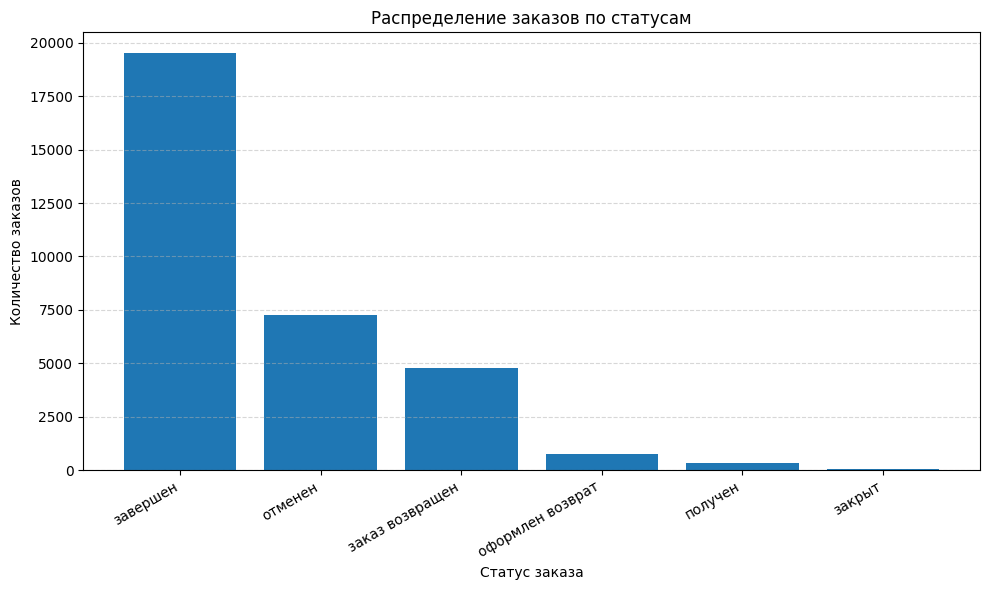

In [12]:
# @title 10. Распределение заказов по статусам (график)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(
    status_distribution['статус'],
    status_distribution['количество_заказов']
)

plt.title('Распределение заказов по статусам')
plt.xlabel('Статус заказа')
plt.ylabel('Количество заказов')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
# @title 11. Динамика продаж по месяцам (таблица)

sales_dynamics = (
    df
    .assign(месяц=df['дата_создания'].dt.to_period('M'))
    .groupby('месяц')
    .agg(
        количество_заказов=('итоговая_сумма', 'count'),
        выручка=('итоговая_сумма', 'sum'),
        средний_чек=('итоговая_сумма', 'mean')
    )
    .reset_index()
)

sales_dynamics['месяц'] = sales_dynamics['месяц'].astype(str)

display(sales_dynamics)

,месяц,количество_заказов,выручка,средний_чек
0,2021-01,3165,14777724.0,4669.107109
1,2021-02,2408,9497376.0,3944.093023
2,2021-03,2714,13510298.0,4978.002211
3,2021-04,2299,11006031.0,4787.312310
4,2021-05,2168,11167902.0,5151.246310
5,2021-06,1976,13965906.0,7067.766194
6,2021-07,1919,11493135.0,5989.127150
7,2021-08,2279,10190720.0,4471.575252
8,2021-09,2090,11026230.0,5275.708134
9,2021-10,2128,9838559.0,4623.382989


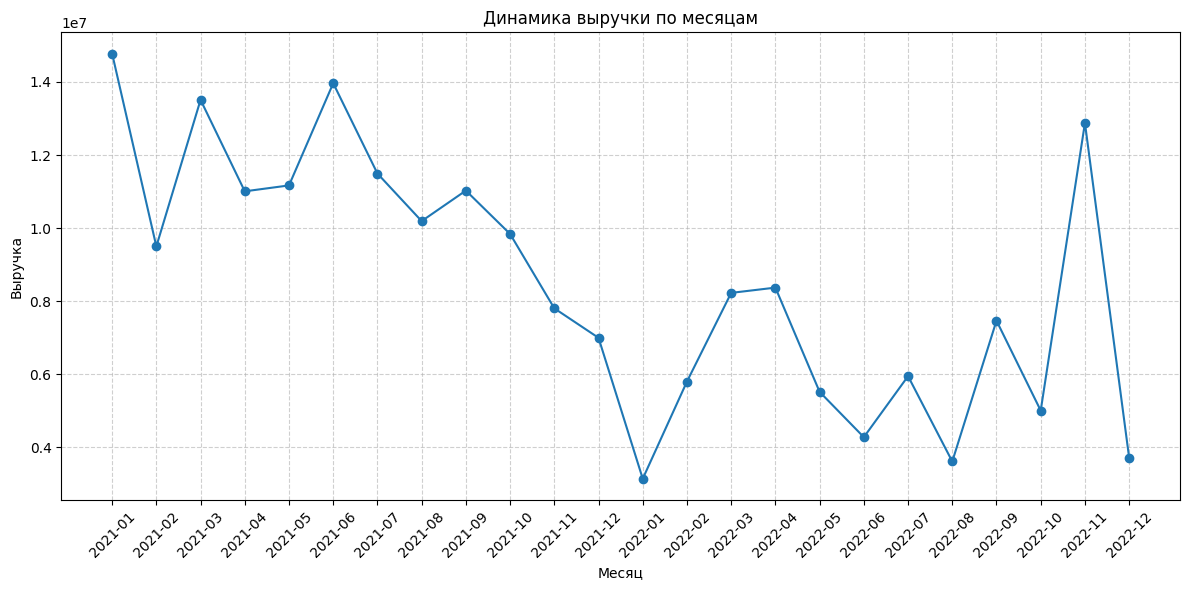

In [14]:
# @title 12. Динамика выручки по месяцам

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(
    sales_dynamics['месяц'],
    sales_dynamics['выручка'],
    marker='o'
)

plt.title('Динамика выручки по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [15]:
# @title 13. Общие ключевые метрики (GMV и средний чек)

total_gmv = df['итоговая_сумма'].sum()
average_check = df['итоговая_сумма'].mean()

metrics = pd.DataFrame({
    'Метрика': ['Общий GMV', 'Средний чек'],
    'Значение': [round(total_gmv, 2), round(average_check, 2)]
})

display(metrics)

,Метрика,Значение
0,Общий GMV,205190866.0
1,Средний чек,6278.6


In [16]:
# @title 14. Средний чек по клиентам

avg_check_per_client = (
    df
    .groupby('id_клиента', as_index=False)
    .agg(
        количество_заказов=('итоговая_сумма', 'count'),
        средний_чек=('итоговая_сумма', 'mean'),
        общая_сумма=('итоговая_сумма', 'sum')
    )
)

display(avg_check_per_client.head())

,id_клиента,количество_заказов,средний_чек,общая_сумма
0,1e4f1,1,1950.0,1950.0
1,1e4f10,2,366.0,732.0
2,1e4f100,2,999.0,1998.0
3,1e4f10002,1,22999.0,22999.0
4,1e4f10008,1,499.0,499.0


In [17]:
# @title 15. GMV по категориям

gmv_by_category = (
    df
    .groupby('категория', as_index=False)
    .agg(
        gmv=('итоговая_сумма', 'sum'),
        количество_заказов=('итоговая_сумма', 'count')
    )
    .sort_values('gmv', ascending=False)
)

gmv_by_category['доля_%'] = (
    gmv_by_category['gmv'] / gmv_by_category['gmv'].sum() * 100
).round(2)

display(gmv_by_category)

,категория,gmv,количество_заказов,доля_%
10,мобильные телефоны и планшеты,116719204.0,5276,56.88
0,бытовая техника,17113891.0,1555,8.34
12,развлечения,16298333.0,605,7.94
11,мужская мода,11200966.0,6872,5.46
8,компьютерная техника,11047462.0,607,5.38
5,женская мода,9829302.0,2325,4.79
9,красота и уход,6207810.0,4023,3.03
13,традиционные подарки,4491940.0,5604,2.19
3,дом и быт,4167343.0,1236,2.03
2,дети и младенцы,2672226.0,1570,1.30


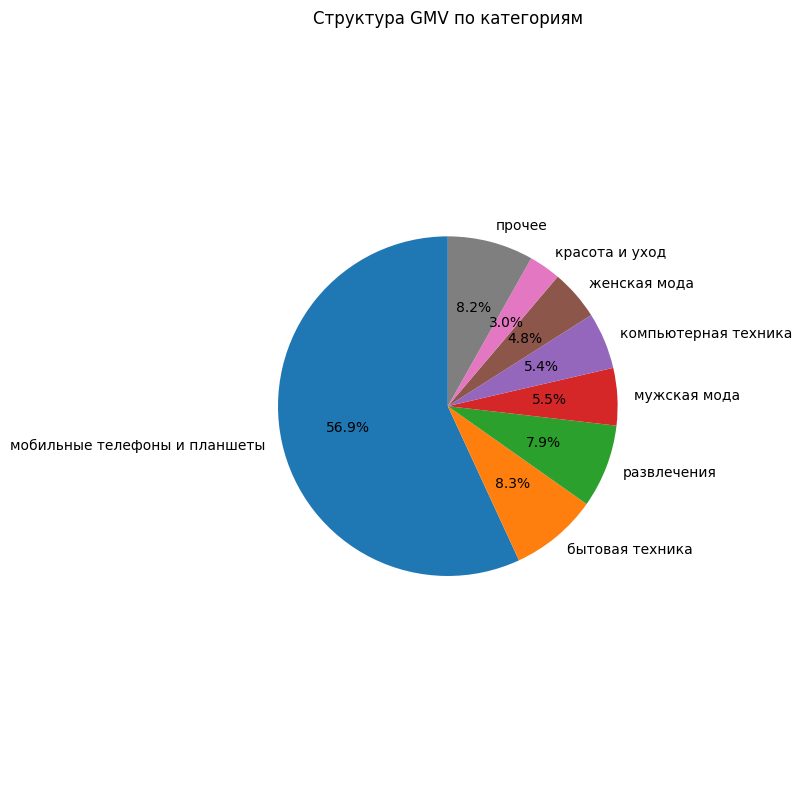

In [18]:
# @title 16. Структура GMV по категориям

import matplotlib.pyplot as plt

threshold = 3  # минимальная доля категории, %

main = gmv_by_category[gmv_by_category['доля_%'] >= threshold]
other = gmv_by_category[gmv_by_category['доля_%'] < threshold]

gmv_pie = pd.concat([
    main,
    pd.DataFrame({
        'категория': ['прочее'],
        'gmv': [other['gmv'].sum()],
        'количество_заказов': [other['количество_заказов'].sum()],
        'доля_%': [other['доля_%'].sum()]
    })
])

plt.figure(figsize=(8, 8))
plt.pie(
    gmv_pie['gmv'],
    labels=gmv_pie['категория'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Структура GMV по категориям')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [19]:
# @title 17. Доли отмен по категориям

df['is_canceled'] = df['статус'].eq('отменен')

cancel_stats = (
    df
    .groupby('категория')
    .agg(
        всего_заказов=('статус', 'count'),
        отменено=('is_canceled', 'sum')
    )
    .reset_index()
)

cancel_stats['доля_отмен_%'] = (
    cancel_stats['отменено'] / cancel_stats['всего_заказов'] * 100
).round(2)

cancel_stats = cancel_stats.sort_values('доля_отмен_%', ascending=False)

display(cancel_stats)

,категория,всего_заказов,отменено,доля_отмен_%
12,развлечения,605,368,60.83
10,мобильные телефоны и планшеты,5276,2499,47.37
8,компьютерная техника,607,256,42.17
4,другое,456,186,40.79
0,бытовая техника,1555,529,34.02
5,женская мода,2325,544,23.40
6,здоровье и спорт,930,162,17.42
3,дом и быт,1236,194,15.70
2,дети и младенцы,1570,239,15.22
7,книги,175,25,14.29


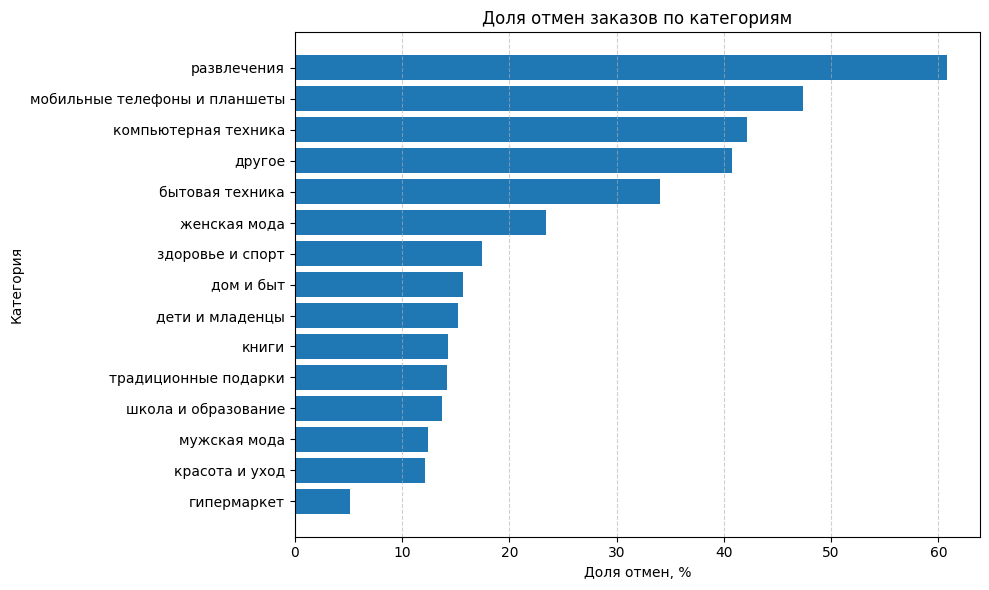

In [20]:
# @title 18. Доли отмен по категориям (график)

import matplotlib.pyplot as plt

min_orders = 100
plot_df = cancel_stats[cancel_stats['всего_заказов'] >= min_orders]

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df['категория'],
    plot_df['доля_отмен_%']
)

plt.xlabel('Доля отмен, %')
plt.ylabel('Категория')
plt.title('Доля отмен заказов по категориям')

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [21]:
# @title 19. ТОП-10 самых продаваемых товаров

sales_df = df[df['статус'] == 'завершен']

top_products = (
    sales_df
    .groupby(['id_товара', 'артикул_товара'], as_index=False)
    .agg(
        продано_единиц=('количество_заказов', 'sum'),
        выручка_GMV=('итоговая_сумма', 'sum')
    )
    .sort_values('продано_единиц', ascending=False)
    .head(10)
)

display(top_products)

,id_товара,артикул_товара,продано_единиц,выручка_GMV
7226,256320.0,shahi_buy one get one free shahi dal moong,100.0,8755.0
8392,258652.0,rs_plain rusk,50.0,2750.0
9420,261230.0,rs_plain rusk,50.0,2750.0
7167,256197.0,rs_plain rusk,50.0,2750.0
7228,256325.0,shahi_buy one get one free shahi savory mix,25.0,4675.0
4985,236860.0,topline_waheed murad his life and our times,20.0,6000.0
4312,228724.0,bparcel_2600mah-red,20.0,5800.0
18139,384153.0,rs_nan khatai,20.0,4200.0
16626,380304.0,rs_plain rusk pack of 3,20.0,3300.0
16586,380197.0,rs_plain rusk pack of 3,20.0,0.0


In [22]:
# @title 20. ТОП-10 товаров по выручке (GMV)

top_products_gmv = (
    sales_df
    .groupby(['id_товара', 'артикул_товара'], as_index=False)
    .agg(
        выручка_GMV=('итоговая_сумма', 'sum'),
        продано_единиц=('количество_заказов', 'sum')
    )
    .sort_values('выручка_GMV', ascending=False)
    .head(10)
)

display(top_products_gmv)

,id_товара,артикул_товара,выручка_GMV,продано_единиц
10097,272497.0,huawei p8 lite,131994.0,6.0
3635,227024.0,sony_dz 350,99049.0,1.0
3636,227025.0,samsung galaxy note-5,99049.0,1.0
16271,379347.0,apple iphone 6s plus 16gb silver,96500.0,1.0
17106,381533.0,apple iphone 6s plus 16gb silver,96500.0,1.0
11587,275924.0,elite_evaporative air cooler,95499.0,1.0
11588,275925.0,samsunggalaxy s-7 edge 32gb lte,95499.0,1.0
16729,380569.0,samsung_k6000 49'',88809.0,1.0
17456,382378.0,infinix hot 4-black,88393.0,7.0
18877,385879.0,omega_bs-1200p,85203.0,1.0


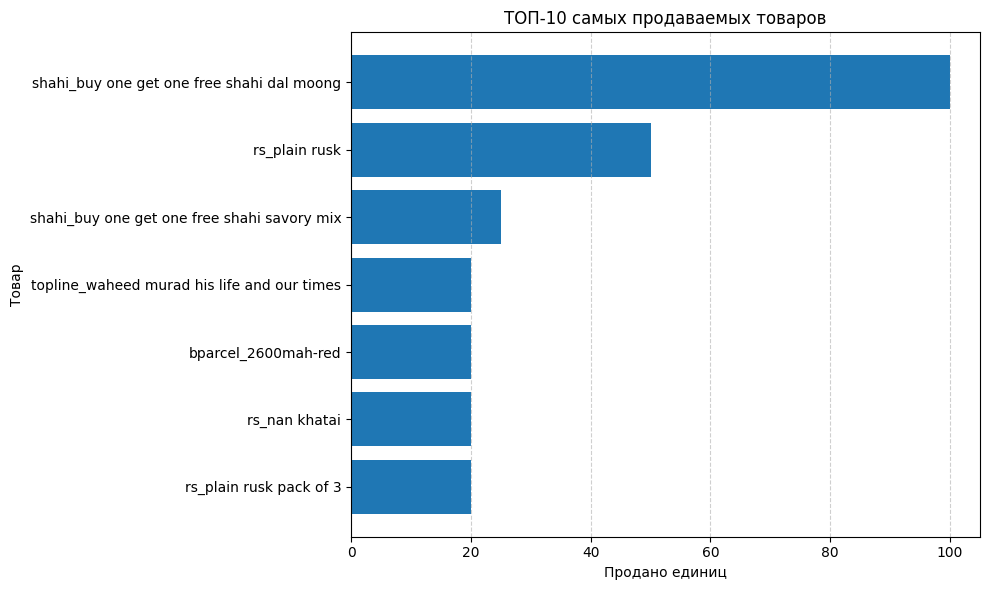

In [23]:
# @title 21. Визуализация ТОП-10 товаров

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(
    top_products['артикул_товара'],
    top_products['продано_единиц']
)

plt.xlabel('Продано единиц')
plt.ylabel('Товар')
plt.title('ТОП-10 самых продаваемых товаров')

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [24]:
# @title 22. ТОП-10 клиентов по выручке

top_clients = (
    df
    .groupby('id_клиента', as_index=False)
    .agg(
        количество_заказов=('итоговая_сумма', 'count'),
        общая_выручка=('итоговая_сумма', 'sum'),
        средний_чек=('итоговая_сумма', 'mean')
    )
    .sort_values('общая_выручка', ascending=False)
    .head(10)
)

display(top_clients)

,id_клиента,количество_заказов,общая_выручка,средний_чек
411,1e4f10654,234,12672835.0,54157.414530
9035,1e4f8963,215,5775906.0,26864.679070
2169,1e4f13793,137,5260723.0,38399.437956
5131,1e4f28952,126,4496044.0,35682.888889
1165,1e4f12178,82,3260481.0,39761.963415
1166,1e4f12179,153,3066818.0,20044.562092
5566,1e4f30310,62,2685444.0,43313.612903
3681,1e4f26527,169,2613985.0,15467.366864
2088,1e4f13709,48,2358633.0,49138.187500
8593,1e4f740,35,2316767.0,66193.342857


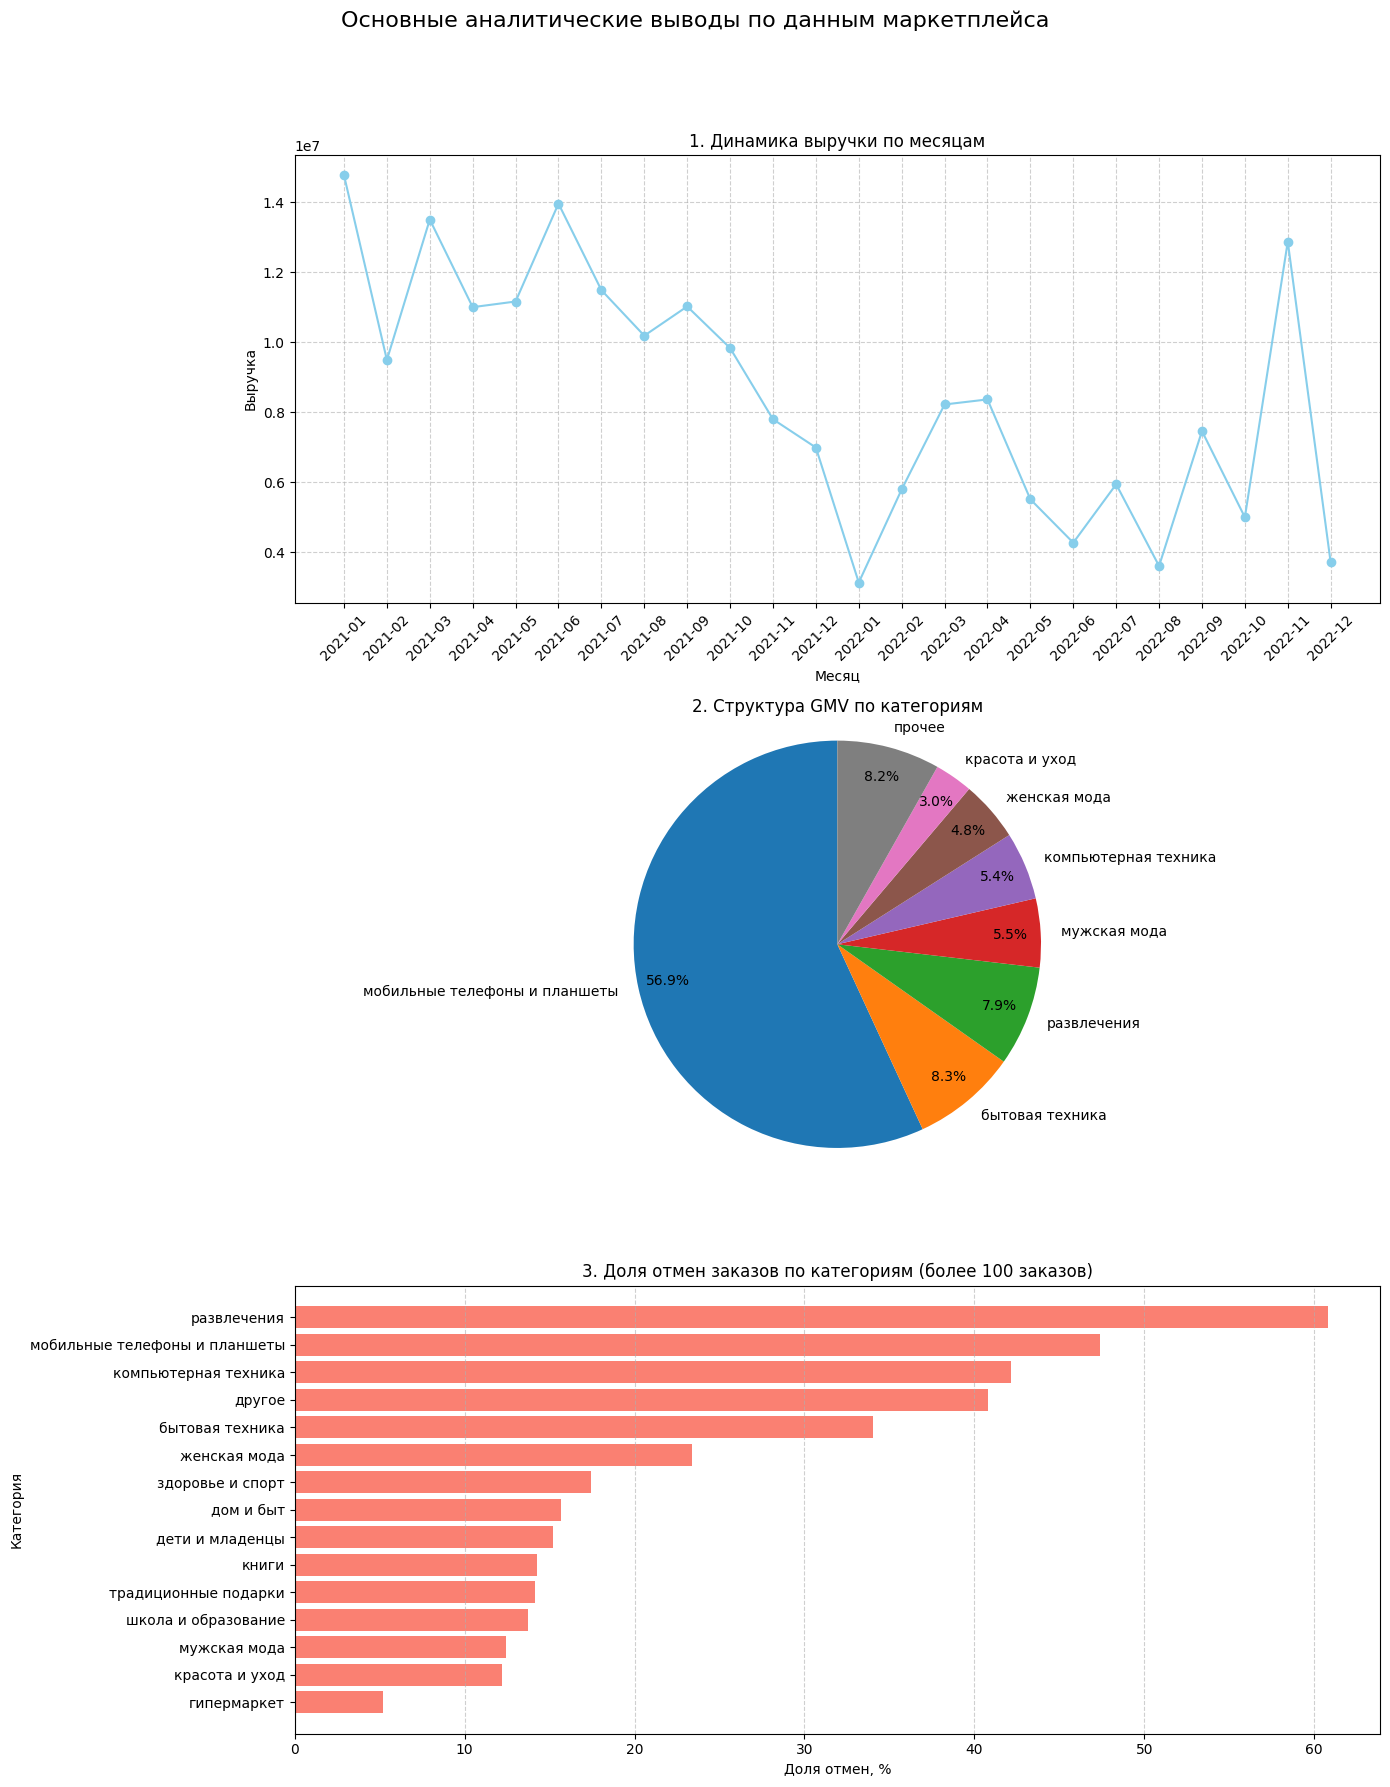

In [25]:
# @title 23. Сводный аналитический дашборд

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle('Основные аналитические выводы по данным маркетплейса', fontsize=16, y=1.02)

# График 1: Динамика выручки по месяцам
axes[0].plot(sales_dynamics['месяц'], sales_dynamics['выручка'], marker='o', color='skyblue')
axes[0].set_title('1. Динамика выручки по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Выручка')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.6)

# График 2: Структура GMV по категориям (круговая диаграмма)
# Используем gmv_pie, уже подготовленный в ячейке 16
axes[1].pie(
    gmv_pie['gmv'],
    labels=gmv_pie['категория'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)
axes[1].set_title('2. Структура GMV по категориям')
axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# График 3: Доли отмен заказов по категориям
# Используем plot_df, уже подготовленный в ячейке 18
axes[2].barh(plot_df['категория'], plot_df['доля_отмен_%'], color='salmon')
axes[2].set_title('3. Доля отмен заказов по категориям (более 100 заказов)')
axes[2].set_xlabel('Доля отмен, %')
axes[2].set_ylabel('Категория')
axes[2].invert_yaxis() # Сверху - категория с самой высокой долей отмен
axes[2].grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

## Задачи второго этапа исследования:

1. Сравнить количество заказов и выручку (GMV) брендов Iphone и Galaxy
2. Проанализировать динамику выручки категории "мобильные телефоны и планшеты"
3. Исследовать динамику выручки по всем остальным товарным категориям
4. Оценить распределение клиентов по количеству заказов и выделить повторных покупателей
5. Проанализировать связь товарной категории с количеством заказов
6. Оценить влияние методов оплаты на вероятность отмены заказа
7. Исследовать распределение клиентов по дате начала обслуживания
8. Рассчитать продолжительность взаимодействия клиента с компанией (Customer Lifetime)

In [31]:
# @title Фильтрация продаж iPhone и Galaxy

iphone_df = df[
    df['артикул_товара']
    .str.contains('iphone', case=False, na=False)
]

galaxy_df = df[
    df['артикул_товара']
    .str.contains('galaxy', case=False, na=False)
]

# Проверка результата
print('iPhone — количество строк:', iphone_df.shape[0])
print('Galaxy — количество строк:', galaxy_df.shape[0])

print('\nУникальные товары iPhone:')
display(iphone_df['артикул_товара'].unique())

print('\nУникальные товары Galaxy:')
display(galaxy_df['артикул_товара'].unique())

iPhone — количество строк: 441
Galaxy — количество строк: 572

Уникальные товары iPhone:


array(['apple iphone 6s 64gb', 'apple iphone 6s 16gb', 'iphone se-16gb',
       'apple iphone 6 (16gb) gold', 'apple iphone 6s plus 128gb',
       'iphone se-64gb', 'apple iphone 6 (128gb) gold',
       'sstop_iphone6pluscameralensprotectorrings',
       'apple iphone 6 plus (16gb) space grey', 'sstop_3miphone',
       'sstop_selfieledlightotg_iphone', 'sstop_iphonehomebutton',
       'sstop_iphone5_colortemperedglass', 'sstop_darkglow_iphone5',
       'copperaccessories_tgjpiphone5', 'apple iphone 6s plus 16gb',
       'apple iphone 5s (16 gb)', 'apple iphone 6 (64gb) silver',
       'sstop_iphone6plus_colortemperedglass',
       'sstop_3diphonecoloredtemperedglass', 'apple iphone 6s plus 64gb',
       'iphone 5s 16gb+getiit joy band_bundle',
       'copperaccessories_tgjpiphone6',
       'laptoys_iphone card read - dual ports - white',
       'apple iphone 6 plus (64gb) gold',
       'apple iphone 6 plus (128gb) space grey',
       'wma_pink and black back case - for iphone 5',
     


Уникальные товары Galaxy:


array(['samsung galaxy j5', 'samsung galaxy j7', 'samsung galaxy s7 edge',
       'samsung galaxy a7 710f (2021)', 'samsung galaxy a3',
       'samsung galaxy note-5', 'samsung galaxy j1 ace',
       'samsung galaxy grand prime g530h',
       'samsung galaxy a5 a510f (2021)', 'samsung galaxy j5.',
       'samsunggalaxy j120f-2021 ds lte',
       'mm_samsung galaxy note edge n915', 'samsung galaxy grand prime',
       'samsunggalaxy s-7 32gb lte',
       'samsung galaxy s6 edge 32gb sm-g925f',
       'samsunggalaxy j510f-2021 ds lte',
       'samsunggalaxy j710f-2021 ds lte',
       'samsunggalaxy s-7 edge 32gb lte', 'samsunggalaxy j3 lte ds qc',
       'wma_baseus-for samsung galaxy s6 edge-transparent',
       'samsung galaxy s6 edge (32gb) sm-g925f gold', 'samsung galaxy j2',
       'samsung galaxy s6 edge plus', 'samsung galaxy grand prime g531h',
       'samsung galaxy s6 - sm-g920f - 32gb single sim',
       'samsunggalaxy j510f-2021 ds lte-samsunggalaxy j510f-2021 ds lte black',


In [33]:
# @title Сравнение продаж iPhone vs Galaxy

comparison = (
    pd.DataFrame({
        'Бренд': ['iPhone', 'Galaxy'],
        'Количество заказов': [
            iphone_df['количество_заказов'].sum(),
            galaxy_df['количество_заказов'].sum()
        ],
        'Общая выручка (GMV)': [
            iphone_df['итоговая_сумма'].sum(),
            galaxy_df['итоговая_сумма'].sum()
        ],
        'Средний чек': [
            iphone_df['итоговая_сумма'].mean(),
            galaxy_df['итоговая_сумма'].mean()
        ]
    })
)

display(comparison)

,Бренд,Количество заказов,Общая выручка (GMV),Средний чек
0,iPhone,450.0,33045398.0,74932.875283
1,Galaxy,614.0,26743656.0,46754.643357


In [1]:
# @title Количество заказов: iPhone vs Galaxy

import matplotlib.pyplot as plt

brands = ['iPhone', 'Galaxy']
orders = [
    iphone_df['количество_заказов'].sum(),
    galaxy_df['количество_заказов'].sum()
]

plt.figure(figsize=(8, 5))
plt.bar(brands, orders)

plt.title('Количество заказов: iPhone vs Galaxy')
plt.ylabel('Количество заказов')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

NameError: name 'iphone_df' is not defined

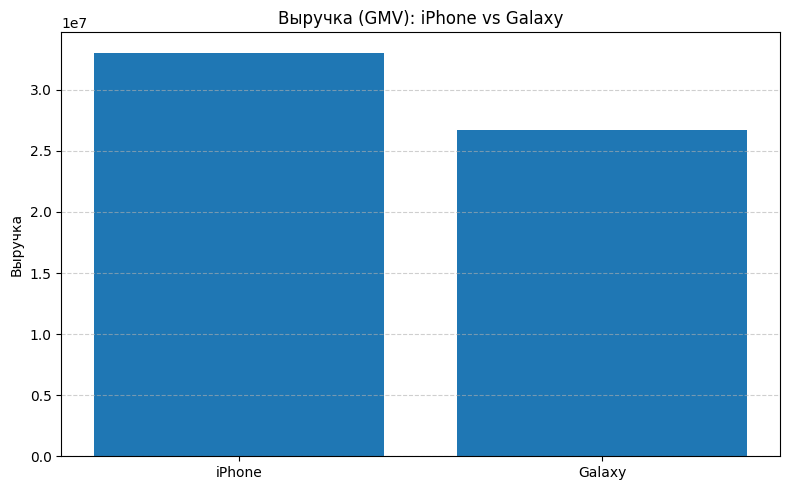

In [36]:
# @title Выручка (GMV): iPhone vs Galaxy

gmv = [
    iphone_df['итоговая_сумма'].sum(),
    galaxy_df['итоговая_сумма'].sum()
]

plt.figure(figsize=(8, 5))
plt.bar(brands, gmv)

plt.title('Выручка (GMV): iPhone vs Galaxy')
plt.ylabel('Выручка')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

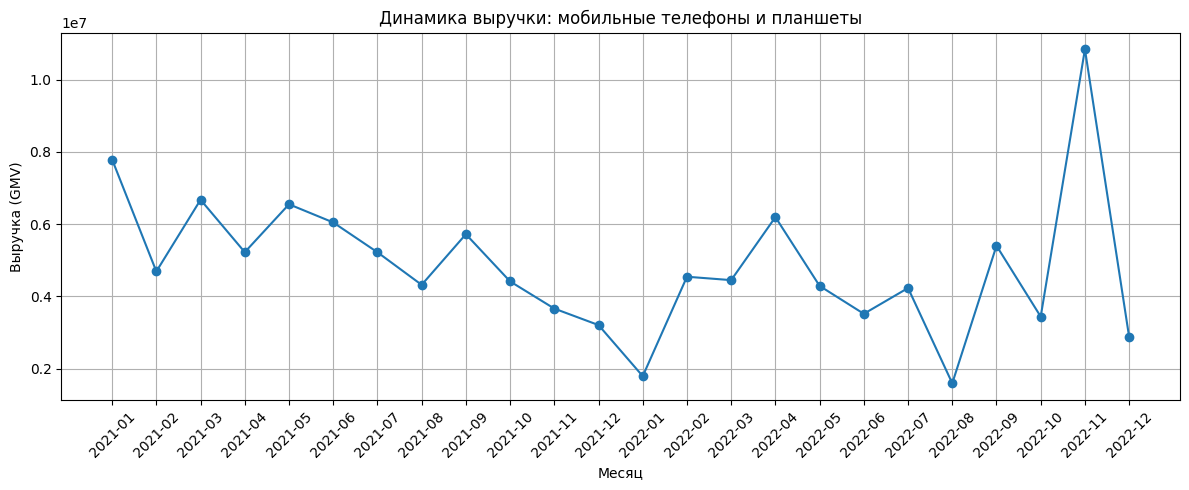

In [38]:
# @title Динамика выручки: мобильные телефоны

phones_df = sales_by_category[
    sales_by_category['категория'] == 'мобильные телефоны и планшеты'
]

plt.figure(figsize=(12, 5))
plt.plot(
    phones_df['месяц'],
    phones_df['выручка'],
    marker='o'
)

plt.title('Динамика выручки: мобильные телефоны и планшеты')
plt.xlabel('Месяц')
plt.ylabel('Выручка (GMV)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

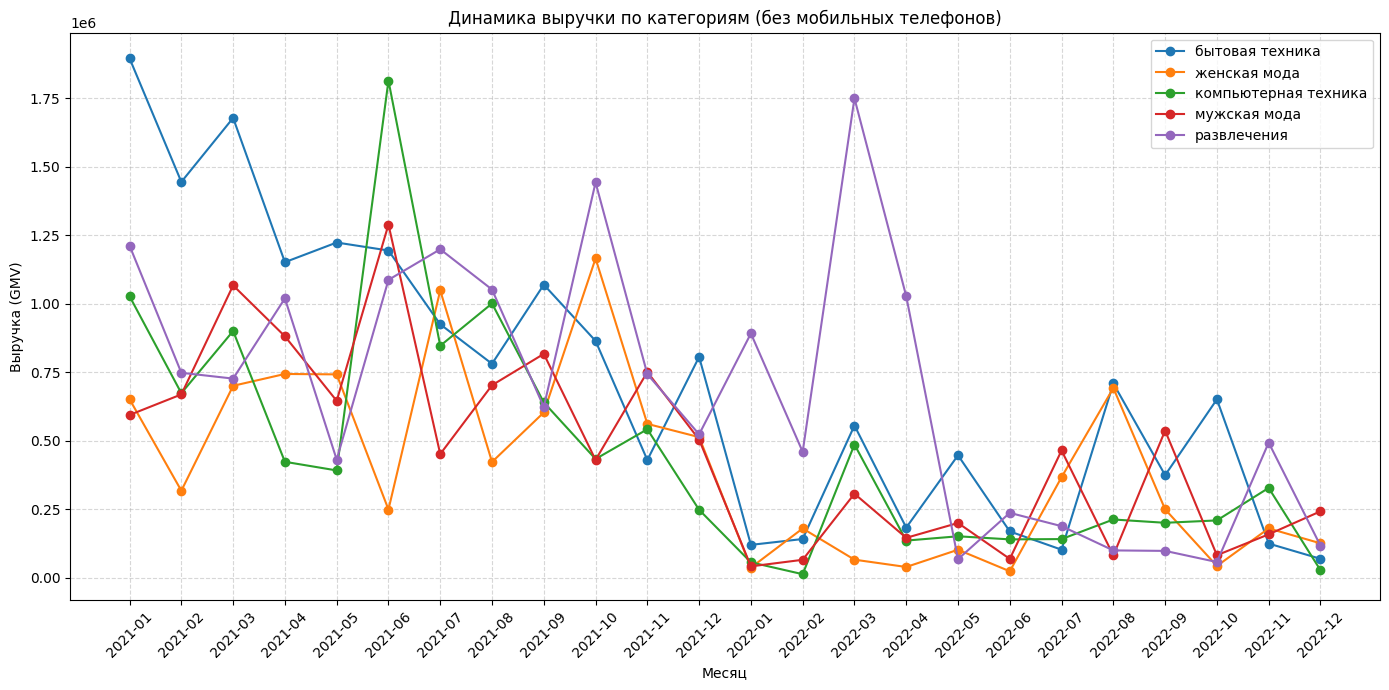

In [39]:
# @title Динамика выручки: остальные категории

other_df = sales_by_category[
    sales_by_category['категория'] != 'мобильные телефоны и планшеты'
]

plt.figure(figsize=(14, 7))

for category in other_df['категория'].unique():
    data = other_df[other_df['категория'] == category]
    plt.plot(data['месяц'], data['выручка'], marker='o', label=category)

plt.title('Динамика выручки по категориям (без мобильных телефонов)')
plt.xlabel('Месяц')
plt.ylabel('Выручка (GMV)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [40]:
# @title 23. Количество заказов на клиента

orders_per_client = (
    df
    .groupby('id_клиента')
    .size()
    .reset_index(name='количество_заказов')
)

display(orders_per_client.head())

,id_клиента,количество_заказов
0,1e4f1,1
1,1e4f10,2
2,1e4f100,2
3,1e4f10002,1
4,1e4f10008,1


In [41]:
# @title 24. Классификация клиентов

single_buyers = orders_per_client[orders_per_client['количество_заказов'] == 1]
repeat_buyers = orders_per_client[orders_per_client['количество_заказов'] > 1]

total_clients = orders_per_client.shape[0]
single_count = single_buyers.shape[0]
repeat_count = repeat_buyers.shape[0]

repeat_share = repeat_count / total_clients * 100
single_share = single_count / total_clients * 100

print(f'Всего клиентов: {total_clients}')
print(f'Разовые покупатели: {single_count} ({single_share:.2f}%)')
print(f'Повторные покупатели: {repeat_count} ({repeat_share:.2f}%)')

Всего клиентов: 9291
Разовые покупатели: 5485 (59.04%)
Повторные покупатели: 3806 (40.96%)


In [46]:
# @title Корреляция категории и количества заказов (с p-value и интерпретацией)

import pandas as pd
from scipy.stats import pointbiserialr

results = []

for category in df['категория'].unique():
    # бинарный признак: принадлежит ли заказ категории
    binary_category = (df['категория'] == category).astype(int)

    corr, p_value = pointbiserialr(binary_category, df['количество_заказов'])

    # автоматическая интерпретация силы связи
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        strength = 'очень слабая'
    elif abs_corr < 0.3:
        strength = 'слабая'
    elif abs_corr < 0.5:
        strength = 'умеренная'
    else:
        strength = 'сильная'

    # статистическая значимость
    significance = 'значима' if p_value < 0.05 else 'не значима'

    results.append({
        'категория': category,
        'корреляция': round(corr, 3),
        'p_value': round(p_value, 5),
        'сила_связи': strength,
        'статистическая_значимость': significance
    })

correlation_df = (
    pd.DataFrame(results)
    .sort_values(by='корреляция', key=lambda x: abs(x), ascending=False)
)

display(correlation_df)

,категория,корреляция,p_value,сила_связи,статистическая_значимость
2,традиционные подарки,0.057,0.00000,очень слабая,значима
11,гипермаркет,0.030,0.00000,очень слабая,значима
5,мужская мода,-0.021,0.00017,очень слабая,значима
0,женская мода,-0.019,0.00067,очень слабая,значима
3,мобильные телефоны и планшеты,-0.016,0.00296,очень слабая,значима
8,развлечения,-0.012,0.03302,очень слабая,значима
6,дети и младенцы,-0.012,0.02406,очень слабая,значима
9,бытовая техника,-0.009,0.11596,очень слабая,не значима
10,компьютерная техника,-0.008,0.16837,очень слабая,не значима
7,другое,-0.007,0.21223,очень слабая,не значима


In [47]:
# @title Корреляция между использованием метода оплаты и отменой заказа
import pandas as pd
from scipy.stats import pointbiserialr

results_payment = []

for method in df['метод_оплаты'].unique():
    # бинарный признак: использован ли данный метод оплаты в заказе
    binary_payment_method = (df['метод_оплаты'] == method).astype(int)

    # Корреляция между использованием метода оплаты и отменой заказа
    corr, p_value = pointbiserialr(binary_payment_method, df['is_canceled'])

    # автоматическая интерпретация силы связи
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        strength = 'очень слабая'
    elif abs_corr < 0.3:
        strength = 'слабая'
    elif abs_corr < 0.5:
        strength = 'умеренная'
    else:
        strength = 'сильная'

    # статистическая значимость
    significance = 'значима' if p_value < 0.05 else 'не значима'

    results_payment.append({
        'метод_оплаты': method,
        'корреляция': round(corr, 3),
        'p_value': round(p_value, 5),
        'сила_связи': strength,
        'статистическая_значимость': significance
    })

correlation_payment_df = (
    pd.DataFrame(results_payment)
    .sort_values(by='корреляция', key=lambda x: abs(x), ascending=False)
)

display(correlation_payment_df)

,метод_оплаты,корреляция,p_value,сила_связи,статистическая_значимость
0,наложенный платеж,-0.661,0.00000,сильная,значима
9,платежная система payaxis,0.657,0.00000,сильная,значима
2,дебетовая карта raif,0.186,0.00000,слабая,значима
10,ваучер,0.121,0.00000,слабая,значима
1,кредитная карта ubl,0.119,0.00000,слабая,значима
3,клиентский кредит,-0.078,0.00000,очень слабая,значима
5,мобильный банкинг mcb,0.064,0.00000,очень слабая,значима
6,маркетинговые расходы,0.064,0.00000,очень слабая,значима
7,наличные при доставке,-0.032,0.00000,очень слабая,значима
4,nan,-0.017,0.00253,очень слабая,значима


In [48]:
# @title Распределение количества клиентов по дате начала обслуживания

clients_by_start_date = (
    df
    .groupby('дата_начала_обслуживания_клиента')
    ['id_клиента'].nunique()
    .reset_index(name='количество_уникальных_клиентов')
    .sort_values('дата_начала_обслуживания_клиента')
)

display(clients_by_start_date.head())
print(f'\nВсего уникальных дат начала обслуживания: {clients_by_start_date.shape[0]}')
display(clients_by_start_date.tail())

,дата_начала_обслуживания_клиента,количество_уникальных_клиентов
0,2021-07-01,1197
1,2021-08-01,1558
2,2021-09-01,1524
3,2021-10-01,1146
4,2021-11-01,1824



Всего уникальных дат начала обслуживания: 7


,дата_начала_обслуживания_клиента,количество_уникальных_клиентов
2,2021-09-01,1524
3,2021-10-01,1146
4,2021-11-01,1824
5,2021-12-01,1177
6,2022-01-01,865


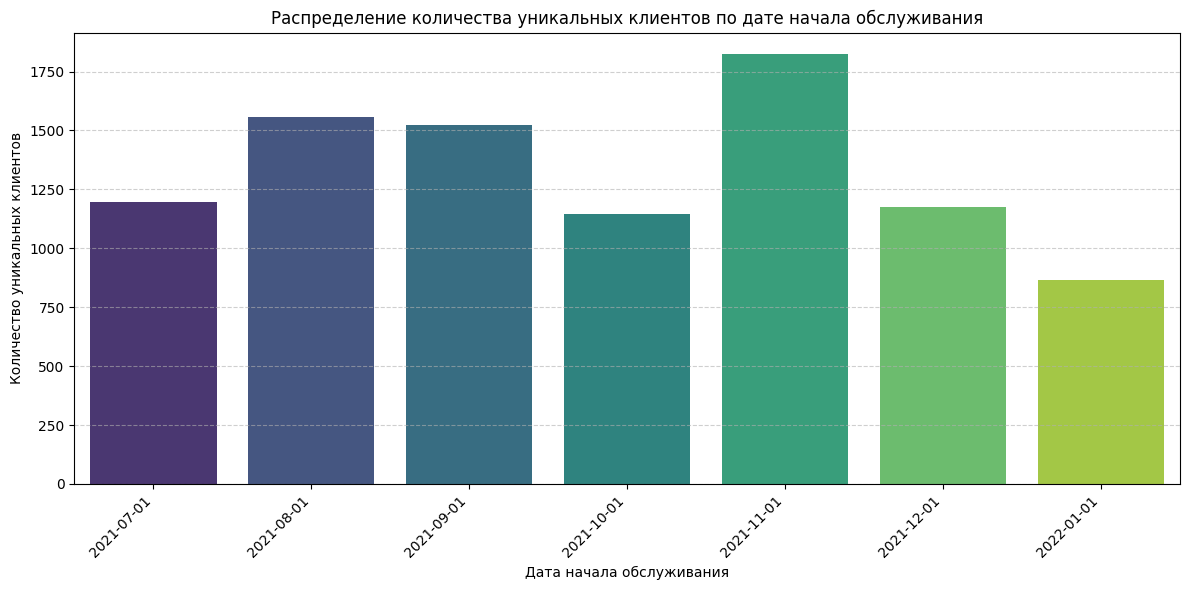

In [50]:
# @title График распределения клиентов по дате начала обслуживания

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    x='дата_начала_обслуживания_клиента',
    y='количество_уникальных_клиентов',
    data=clients_by_start_date,
    palette='viridis',
    hue='дата_начала_обслуживания_клиента', # Добавлено для устранения FutureWarning
    legend=False # Добавлено для устранения FutureWarning, если легенда не нужна
)

plt.title('Распределение количества уникальных клиентов по дате начала обслуживания')
plt.xlabel('Дата начала обслуживания')
plt.ylabel('Количество уникальных клиентов')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [54]:
# @title 27. Расчет Customer Lifetime на момент 2022-02

import pandas as pd

target_date = pd.to_datetime('2022-02-01')

# Для каждого клиента находим дату первого контакта
# Используем уже созданный client_lifetime_data, если он существует, или пересоздаем.
# Если client_lifetime_data еще не существует, то:
# client_lifetime_data = df.groupby('id_клиента').agg(
#     first_contact_date=('дата_начала_обслуживания_клиента', 'min'),
# ).reset_index()

# Убедимся, что client_lifetime_data доступен и содержит first_contact_date
if 'client_lifetime_data' not in locals() or client_lifetime_data.empty:
    client_lifetime_data = df.groupby('id_клиента').agg(
        first_contact_date=('дата_начала_обслуживания_клиента', 'min'),
    ).reset_index()

# Рассчитываем продолжительность взаимодействия до target_date в днях
client_lifetime_data['lifetime_until_2022_02'] = (
    (target_date - client_lifetime_data['first_contact_date']).dt.days
)

# Исправляем отрицательные значения: если first_contact_date позже target_date,
# то устанавливаем lifetime_until_2022_02 в 0.
client_lifetime_data.loc[
    client_lifetime_data['lifetime_until_2022_02'] < 0,
    'lifetime_until_2022_02'
] = 0

print(f'Статистика продолжительности взаимодействия с клиентом (в днях) на момент {target_date.date()}:')
display(client_lifetime_data['lifetime_until_2022_02'].describe())

Статистика продолжительности взаимодействия с клиентом (в днях) на момент 2022-02-01:


,lifetime_until_2022_02
count,9291.000000
mean,127.623937
std,57.350468
min,31.000000
25%,92.000000
50%,123.000000
75%,184.000000
max,215.000000


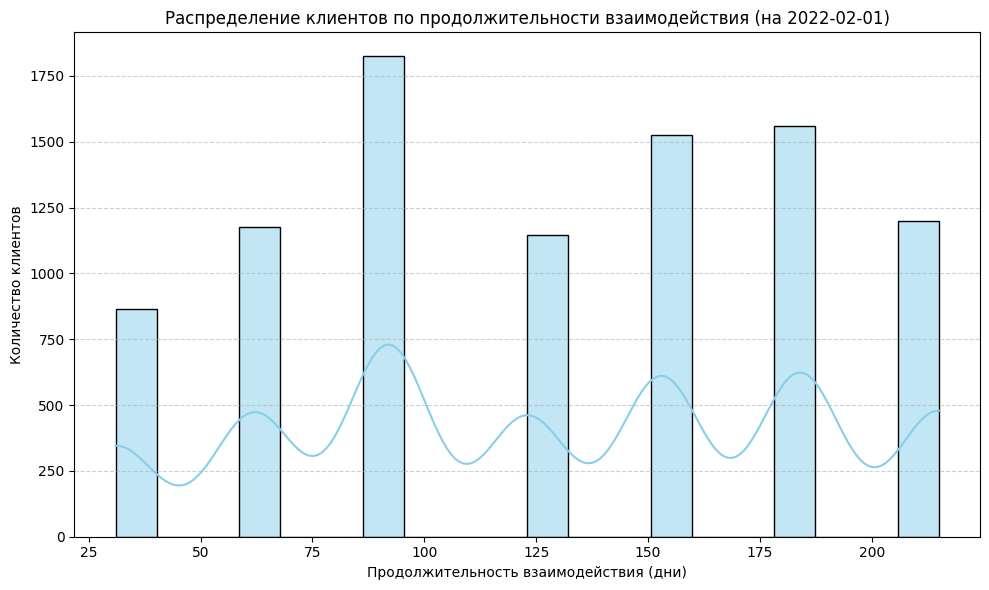

In [55]:
# @title Распределение клиентов по продолжительности взаимодействия (Lifetime)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(
    data=client_lifetime_data,
    x='lifetime_until_2022_02',
    bins=20, # Количество интервалов для гистограммы
    kde=True, # Добавляем оценку плотности ядра для сглаженной линии распределения
    color='skyblue'
)

plt.title('Распределение клиентов по продолжительности взаимодействия (на 2022-02-01)')
plt.xlabel('Продолжительность взаимодействия (дни)')
plt.ylabel('Количество клиентов')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Общие выводы (выводы по первой части есть в развернутом виде в прошлом уроке в формате docx):

1. Количество продаж Galaxy превышает количество продаж Iphone
2. Общая выручка за продажи Iphone больше чем у Galaxy
3. Средний чек продажи Iphone больше чем у Galaxy
4. Продажи всех категорий очень волатильны и не имеют устойчивого спроса
5. Мобильные устройства - ключевая категория продаж
6. Резкое падение спроса в 2022 году
7. Основную долю клиентской базы составляют разовые покупатели
8. Категория товара не определяет поведение клиента с точки зрения повторных покупок
9. Продолжительность взаимодействия с клиентами в среднем составляет около 128 дней
10. При методе оплаты "наложенный платеж" отмены заказов происходят существенно реже
11. При методе оплаты "платежная система payaxis" заказы отменяются чаще
12. Способ оплаты может влиять на отмены заказов

##  Из вышеизложенных данных можем сделать вывод что нужно повышать лояльность клиентов, сделать больший упор на их удержание и проанализировать другие факторы которые могут влиять на высокую волатильность спроса в различных категориях товаров.